In [3]:
import pandas as pd
from functools import reduce


# 1) load
meter = pd.read_csv('2107_meter_15m_data.csv')
env   = pd.read_csv('2107_environment_data.csv')   # check spelling in filename
irr   = pd.read_csv('2107_irradiance_data.csv')


# 2) ensure datetime key, erased meter
for d in [meter, env, irr]:
    d['measured_on'] = pd.to_datetime(d['measured_on'])

# 3) merge all on measured_on, erased meter
dfs = [meter, env, irr]
df_2107_meter = reduce(lambda l, r: pd.merge(l, r, on='measured_on', how='outer'), dfs)

# 4) optional sort/reset
df_2107_meter = df_2107_meter.sort_values('measured_on').reset_index(drop=True)

df_2107_meter = df_2107_meter.dropna()
target = 'meter_revenue_grade_ac_output_meter_149578'   # or your real target column name

# keep rows with target <= threshold
threshold = 1000
df_2107_meter = df_2107_meter[df_2107_meter[target] <= threshold]


df_2107_meter.head()

,measured_on,meter_revenue_grade_ac_output_meter_149578,ambient_temperature_o_149575,wind_speed_o_149576,wind_direction_o_149577,poa_irradiance_o_149574
32621,2017-12-01 00:15:00,0.0,38.8,1.2,156.0,0.0
32628,2017-12-01 01:00:00,0.0,37.0,2.6,247.0,0.0
32634,2017-12-01 01:30:00,0.0,37.0,2.6,247.0,0.0
32637,2017-12-01 01:45:00,0.0,37.0,2.6,247.0,0.0
32640,2017-12-01 02:00:00,0.0,37.5,1.9,265.0,0.0


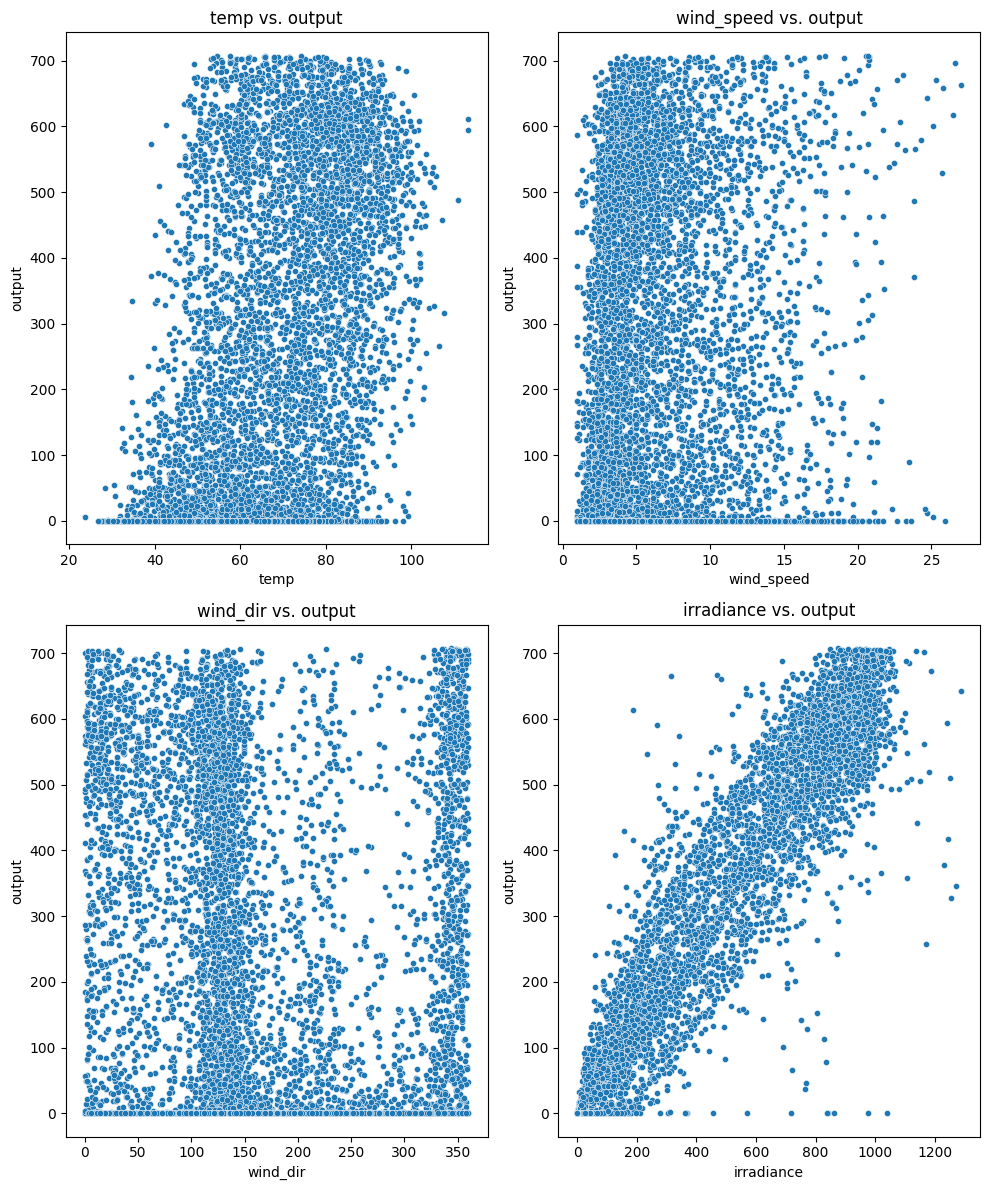

In [41]:
# meter analysis for feature selection
# matplotlib.pyplot is used for creating plots, charts, and visualizations.
import matplotlib.pyplot as plt

# Seaborn is a high-level statistical data visualization library built on Matplotlib
import seaborn as sns

# Define features and target
df_2107_meter_sample = df_2107_meter.sample(10000, random_state=215)

df_2107_meter_sample = df_2107_meter_sample.rename(columns={
    "ambient_temperature_o_149575": "temp",
    "wind_speed_o_149576": "wind_speed",
    "wind_direction_o_149577": "wind_dir",
    "poa_irradiance_o_149574": "irradiance",
    "meter_revenue_grade_ac_output_meter_149578": "output"
})

features = df_2107_meter_sample.columns[2:]
target = df_2107_meter_sample.columns[1]

# Define grid size
n_features = len(features)
n_cols = 2
fig, axes = plt.subplots(2, 2, figsize=(10, 12))
axes = axes.flatten()

# Create scatterplots
for i, feature in enumerate(features):
    sns.scatterplot(x=df_2107_meter_sample[feature], y=df_2107_meter_sample[target], ax=axes[i], edgecolor='w', s=20)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target)
    axes[i].set_title(f'{feature} vs. {target}')

plt.tight_layout()
plt.show()

In [5]:
# time-series 8:2 split (no shuffle)
df_2107_meter['measured_on'] = pd.to_datetime(df_2107_meter['measured_on'])
df_2107_meter = df_2107_meter.sort_values('measured_on').reset_index(drop=True)

split_idx = int(len(df_2107_meter) * 0.8)

train_df = df_2107_meter.iloc[:split_idx].copy()
test_df  = df_2107_meter.iloc[split_idx:].copy()

print(f"train: {len(train_df)} ({len(train_df)/len(df_2107_meter):.1%})")
print(f"test : {len(test_df)} ({len(test_df)/len(df_2107_meter):.1%})")

train: 140147 (80.0%)
test : 35037 (20.0%)


In [ ]:
import numpy as np
import pandas as pd

# Data splits for Validation


# 0) sort by time
df = df_2107_meter.copy()
df['measured_on'] = pd.to_datetime(df['measured_on'])
df = df.sort_values('measured_on').reset_index(drop=True)

# 1) 8:2 split
split_idx = int(len(df) * 0.8)
train_pool = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

# 2) expanding validation checkpoints on train_pool
fractions = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
val_horizon = int(len(train_pool) * 0.2)   # choose your validation size (example: 10%)
val_horizon = max(val_horizon, 1)

splits = []
n = len(train_pool)

for f in fractions:
    end = int(n * f)  # endpoint of usable data for this checkpoint
    if end <= val_horizon:
        continue
    tr_end = end - val_horizon
    tr_idx = np.arange(0, tr_end)
    va_idx = np.arange(tr_end, end)
    splits.append((f, tr_idx, va_idx))

# inspect
for f, tr, va in splits:
    print(f"{int(f*100)}% checkpoint | train={len(tr)} val={len(va)} "
          f"| train[{tr[0]}..{tr[-1]}] val[{va[0]}..{va[-1]}]")

50% checkpoint | train=42044 val=28029 | train[0..42043] val[42044..70072]
60% checkpoint | train=56059 val=28029 | train[0..56058] val[56059..84087]
70% checkpoint | train=70073 val=28029 | train[0..70072] val[70073..98101]
80% checkpoint | train=84088 val=28029 | train[0..84087] val[84088..112116]
90% checkpoint | train=98103 val=28029 | train[0..98102] val[98103..126131]
100% checkpoint | train=112118 val=28029 | train[0..112117] val[112118..140146]


In [34]:
df.iloc[splits[0][1]].head()

,ds,y,ambient_temperature_o_149575,wind_speed_o_149576,wind_direction_o_149577,poa_irradiance_o_149574
0,2017-12-01 00:15:00,0.0,38.8,1.2,156.0,0.0
1,2017-12-01 01:00:00,0.0,37.0,2.6,247.0,0.0
2,2017-12-01 01:30:00,0.0,37.0,2.6,247.0,0.0
3,2017-12-01 01:45:00,0.0,37.0,2.6,247.0,0.0
4,2017-12-01 02:00:00,0.0,37.5,1.9,265.0,0.0


14:07:07 - cmdstanpy - INFO - Chain [1] start processing
14:07:29 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 103743.64783801892


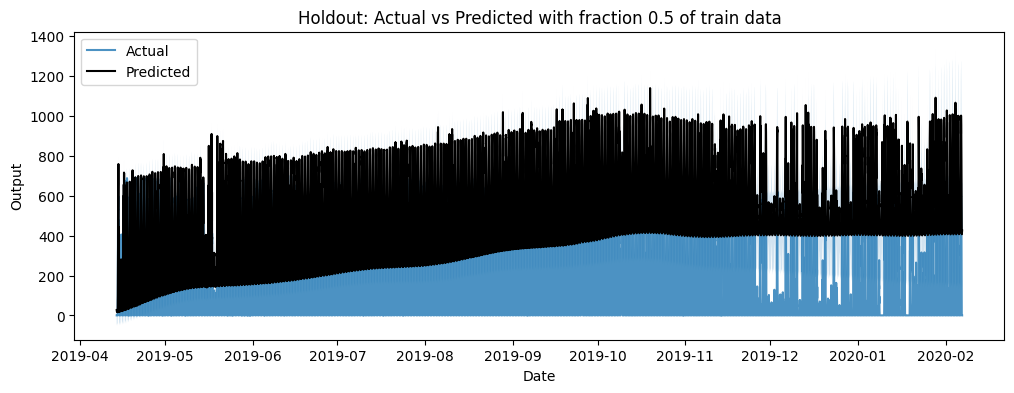

14:07:37 - cmdstanpy - INFO - Chain [1] start processing
14:07:55 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 3388.2076123694064


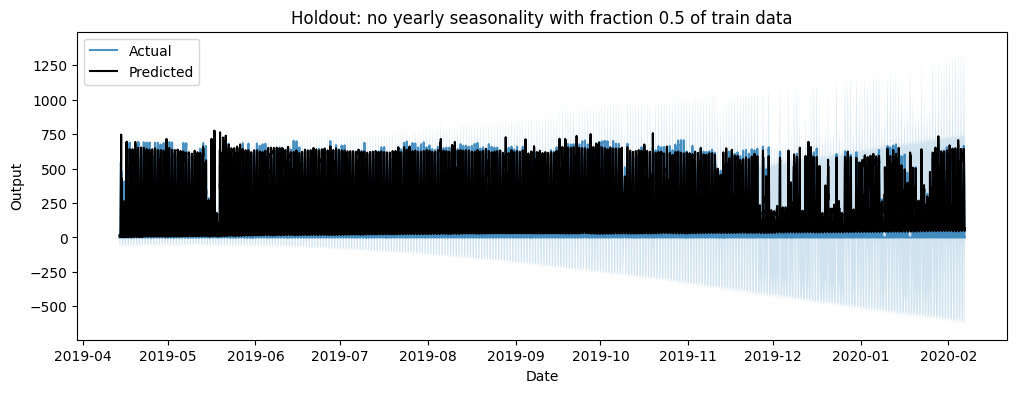

14:08:03 - cmdstanpy - INFO - Chain [1] start processing
14:08:20 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 4164.889693821341


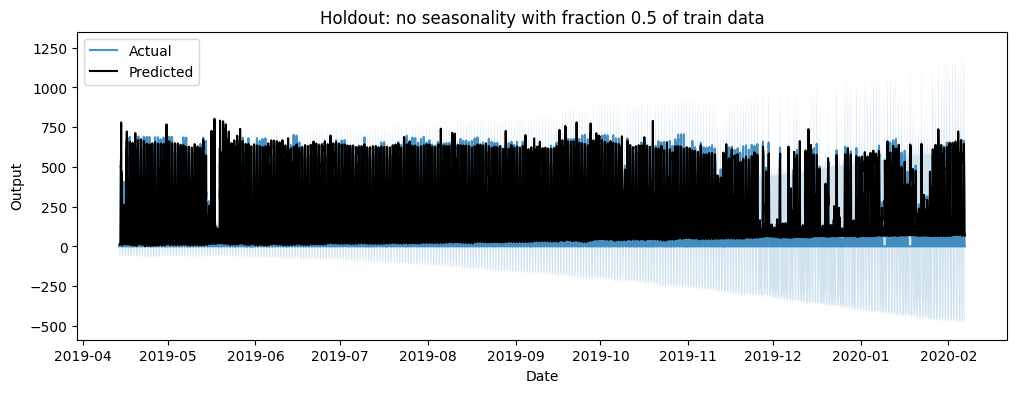

14:08:28 - cmdstanpy - INFO - Chain [1] start processing
14:08:28 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 3422.284808275797


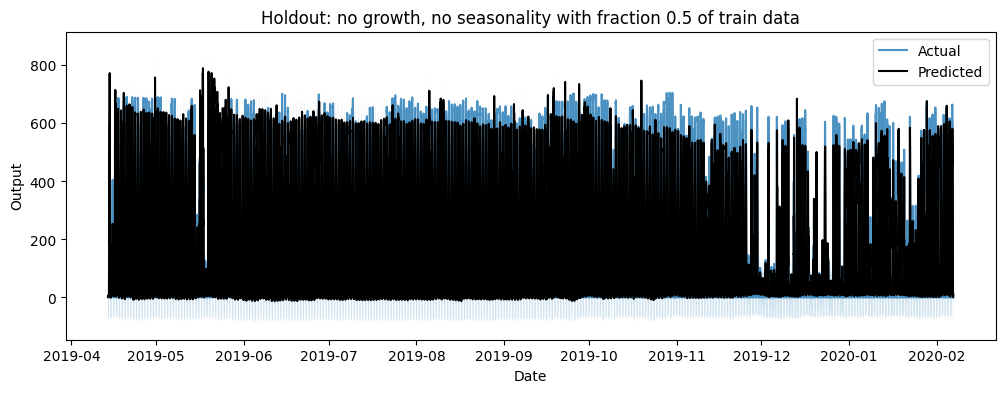

14:08:37 - cmdstanpy - INFO - Chain [1] start processing
14:09:01 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 7433.161439543512


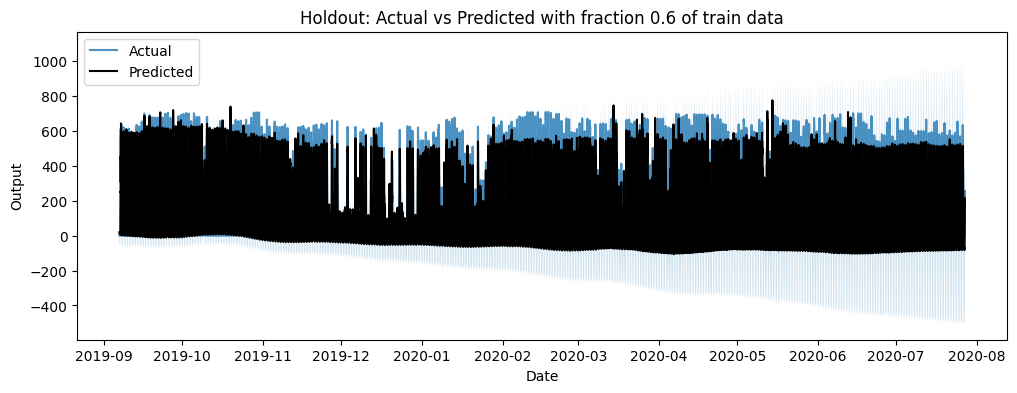

14:09:10 - cmdstanpy - INFO - Chain [1] start processing
14:09:41 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 3915.3820399266547


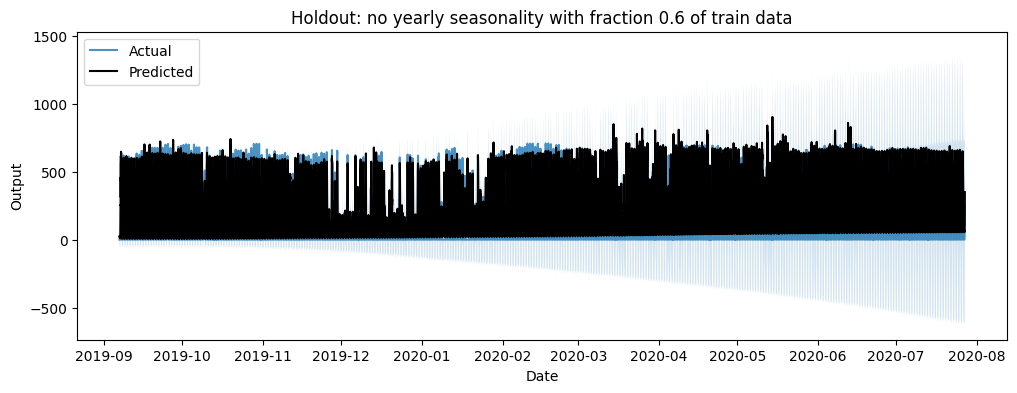

14:09:50 - cmdstanpy - INFO - Chain [1] start processing
14:10:10 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 5790.549382858642


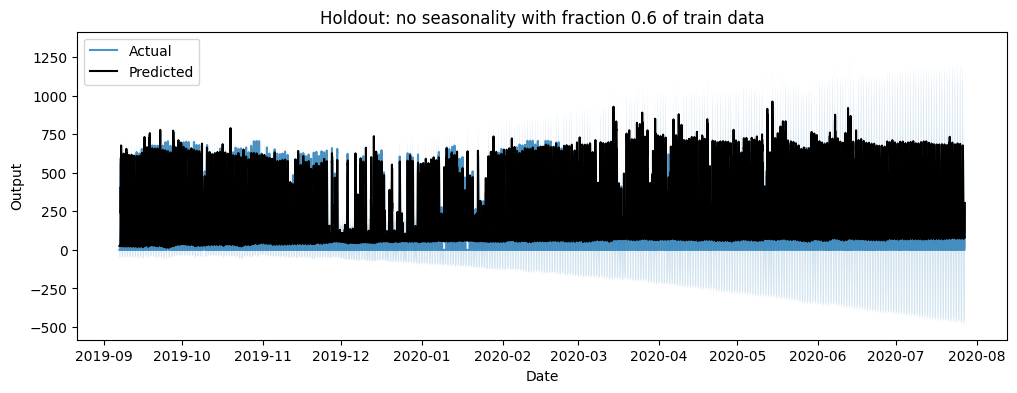

14:10:17 - cmdstanpy - INFO - Chain [1] start processing
14:10:18 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 3939.3990652118555


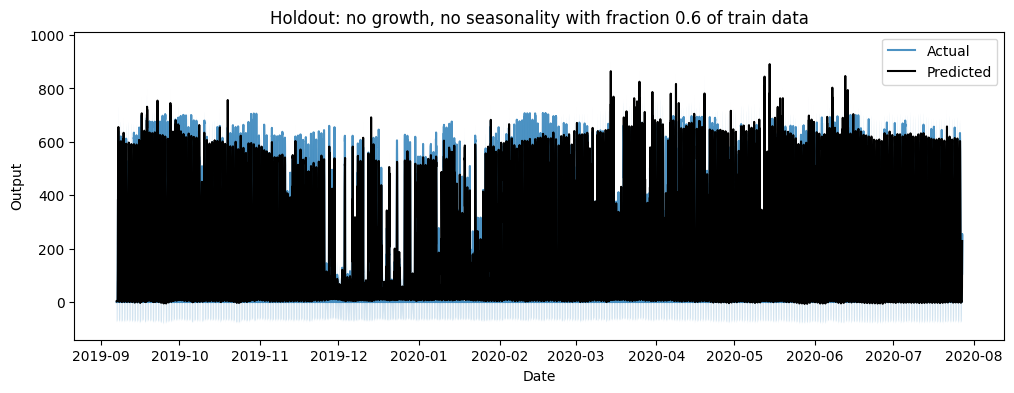

14:10:27 - cmdstanpy - INFO - Chain [1] start processing
14:11:14 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 3121.2239636050713


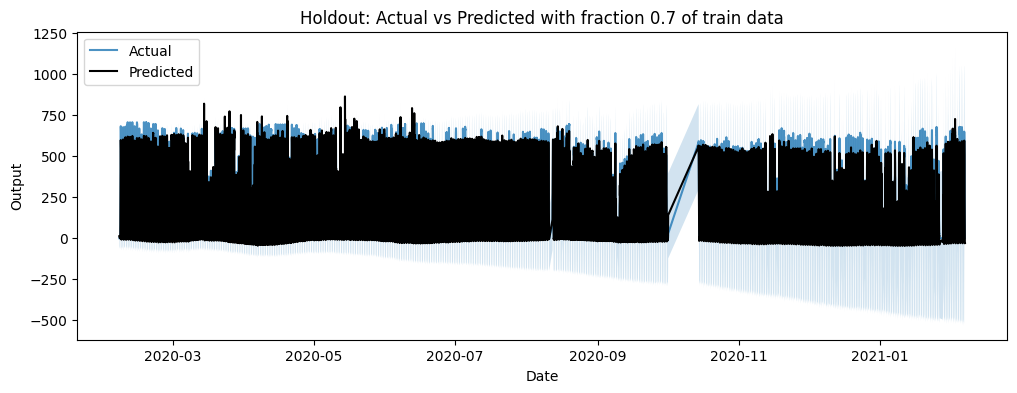

14:11:23 - cmdstanpy - INFO - Chain [1] start processing
14:11:45 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 3276.2096715392854


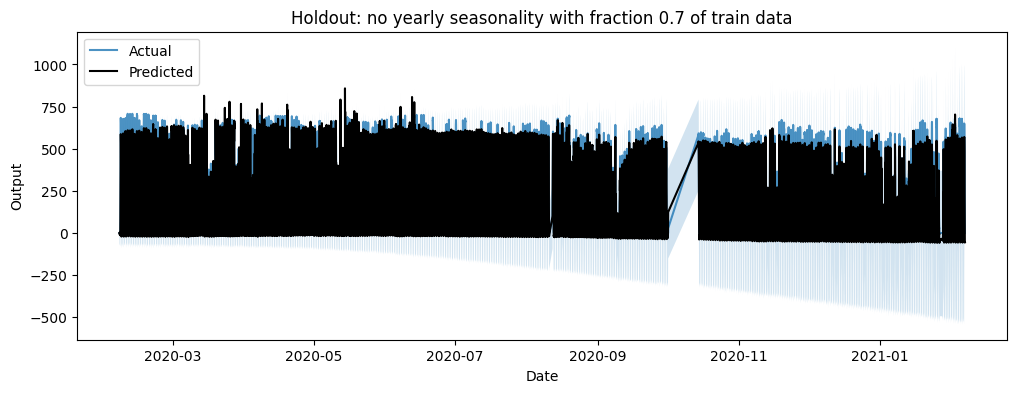

14:11:53 - cmdstanpy - INFO - Chain [1] start processing
14:12:11 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 5298.289035993921


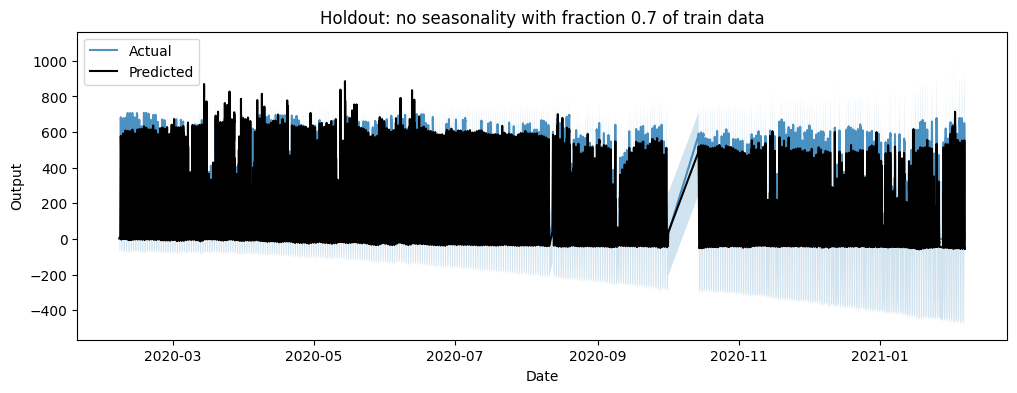

14:12:19 - cmdstanpy - INFO - Chain [1] start processing
14:12:20 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 3722.109069756584


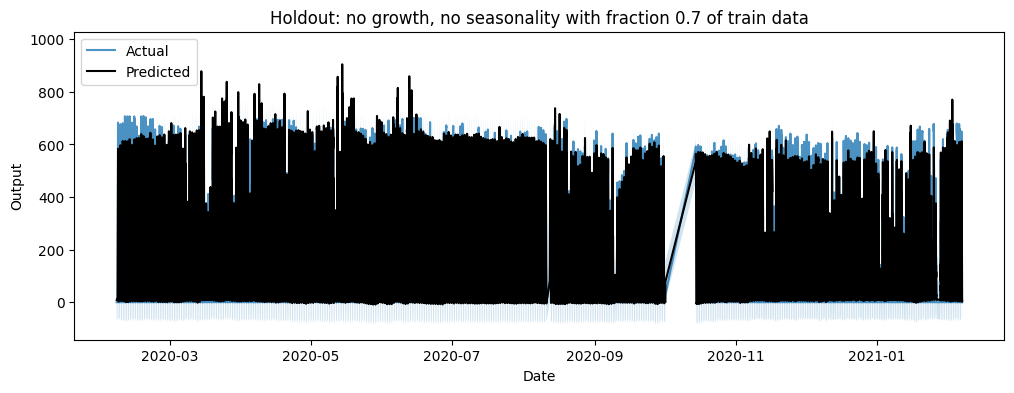

14:12:30 - cmdstanpy - INFO - Chain [1] start processing
14:13:18 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 2351.462573706411


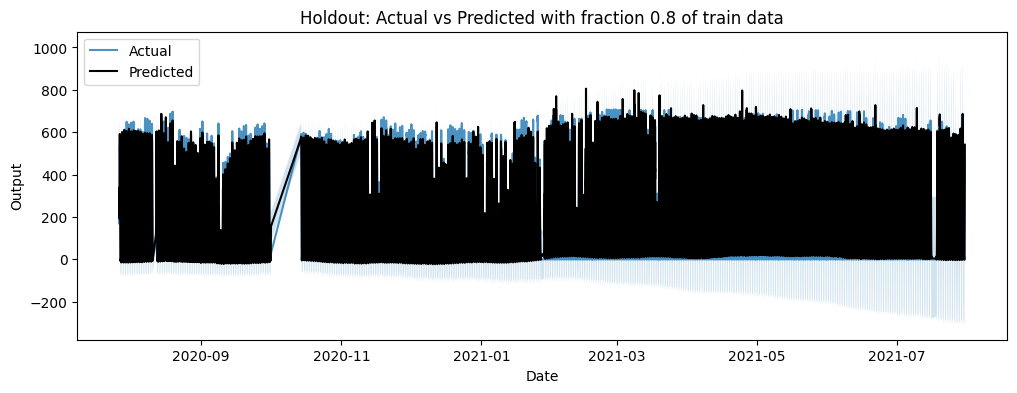

14:13:27 - cmdstanpy - INFO - Chain [1] start processing
14:13:51 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 2343.1344705060833


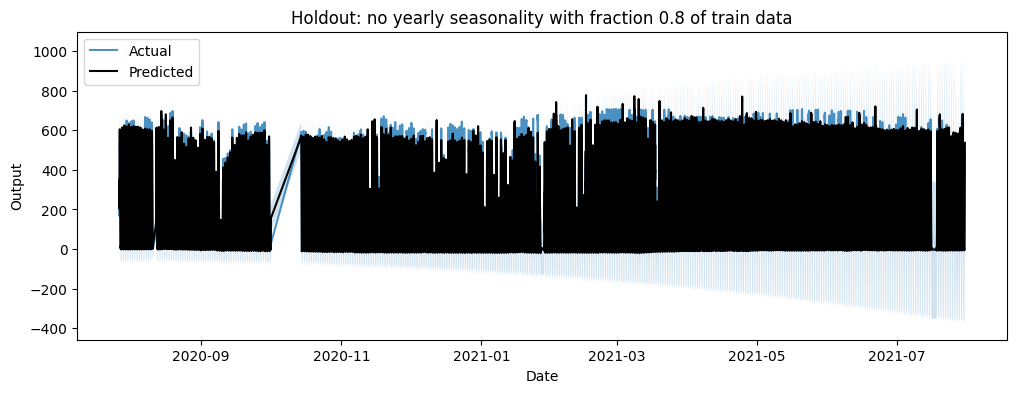

14:13:59 - cmdstanpy - INFO - Chain [1] start processing
14:14:22 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 3415.8506383804806


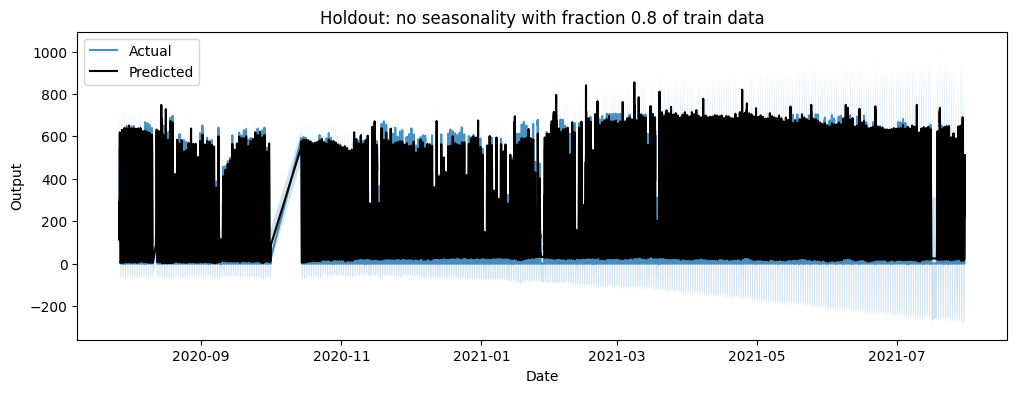

14:14:30 - cmdstanpy - INFO - Chain [1] start processing
14:14:31 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 3247.892617382737


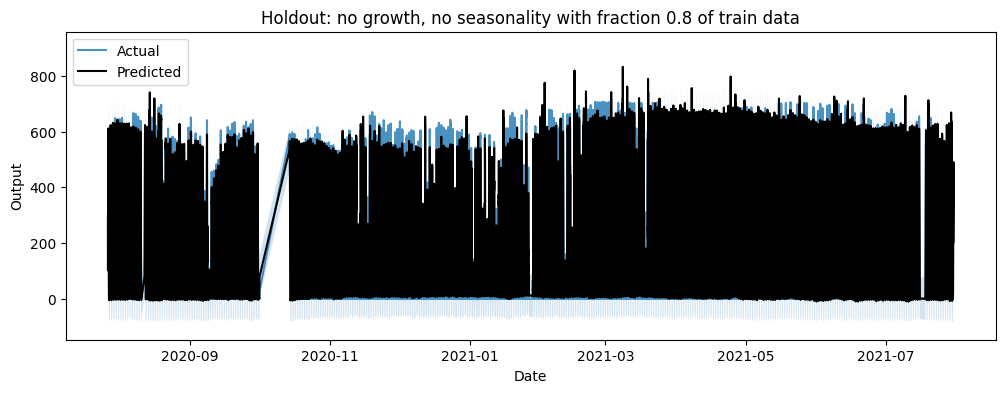

14:14:43 - cmdstanpy - INFO - Chain [1] start processing
14:15:27 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 3315.3710801321804


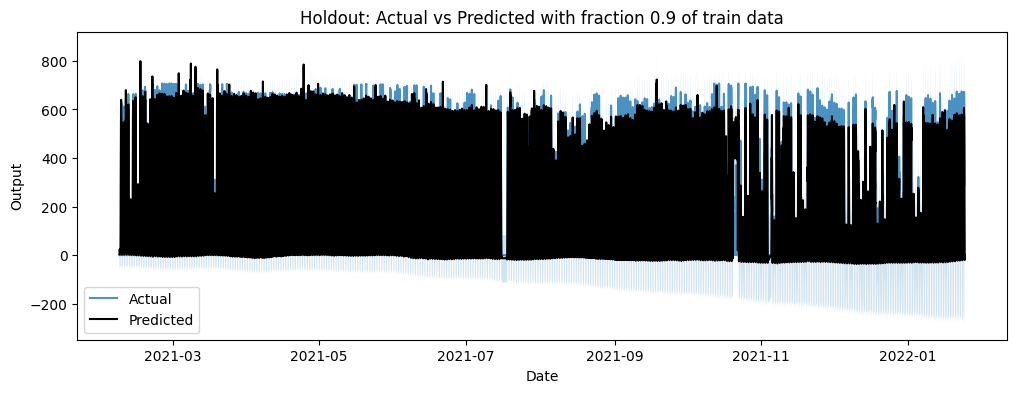

14:15:37 - cmdstanpy - INFO - Chain [1] start processing
14:16:10 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 3397.530629788311


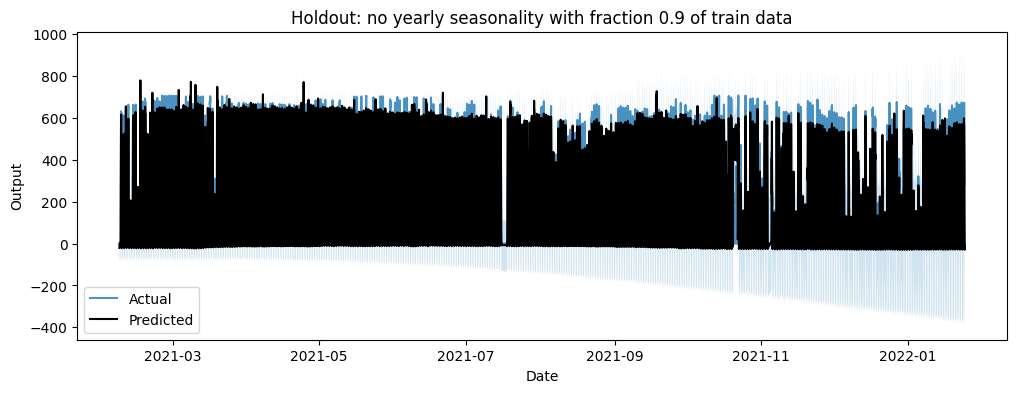

14:16:19 - cmdstanpy - INFO - Chain [1] start processing
14:16:49 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 4640.782806268733


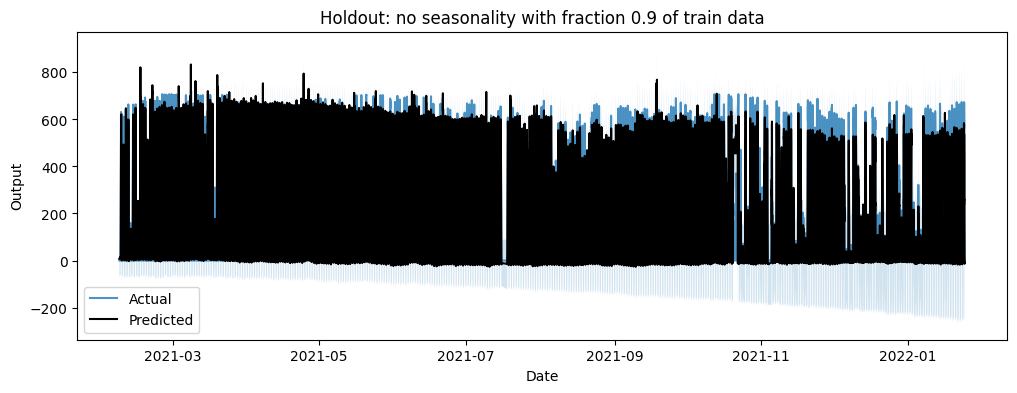

14:16:57 - cmdstanpy - INFO - Chain [1] start processing
14:16:57 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 4399.350557700206


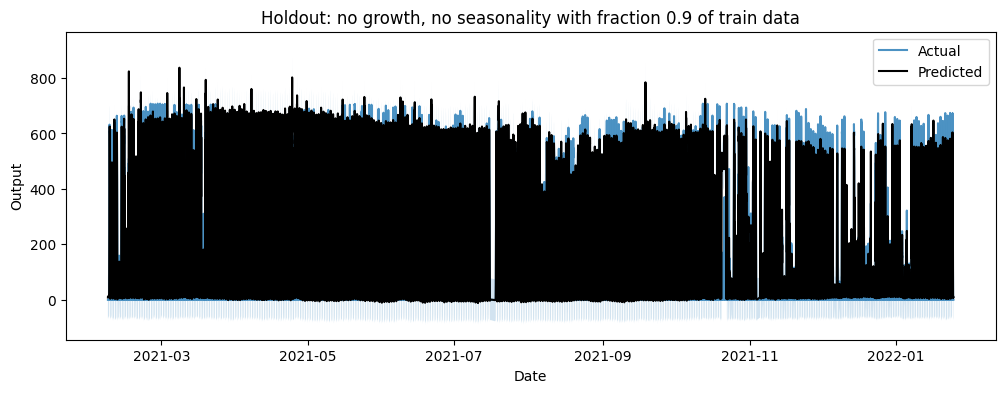

14:17:10 - cmdstanpy - INFO - Chain [1] start processing
14:18:06 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 3708.184132242378


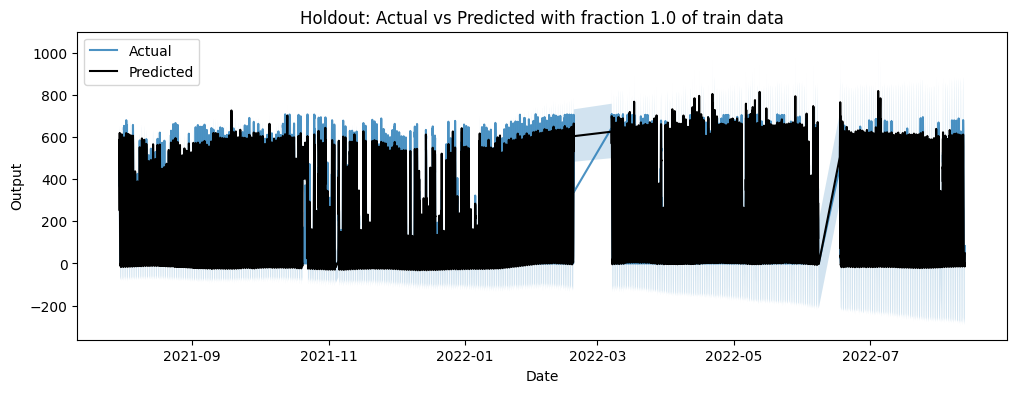

14:18:17 - cmdstanpy - INFO - Chain [1] start processing
14:19:03 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 3905.6568773335744


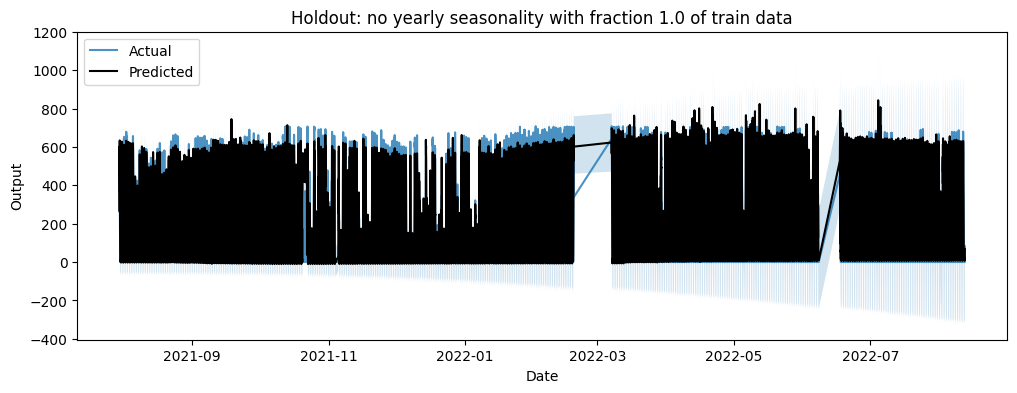

14:19:11 - cmdstanpy - INFO - Chain [1] start processing
14:19:46 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 5069.6388498742845


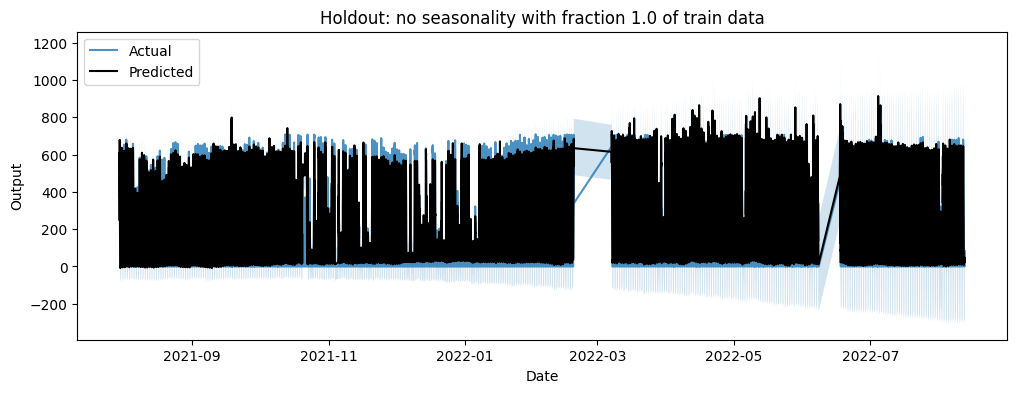

14:19:54 - cmdstanpy - INFO - Chain [1] start processing
14:19:55 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 4925.358682597938


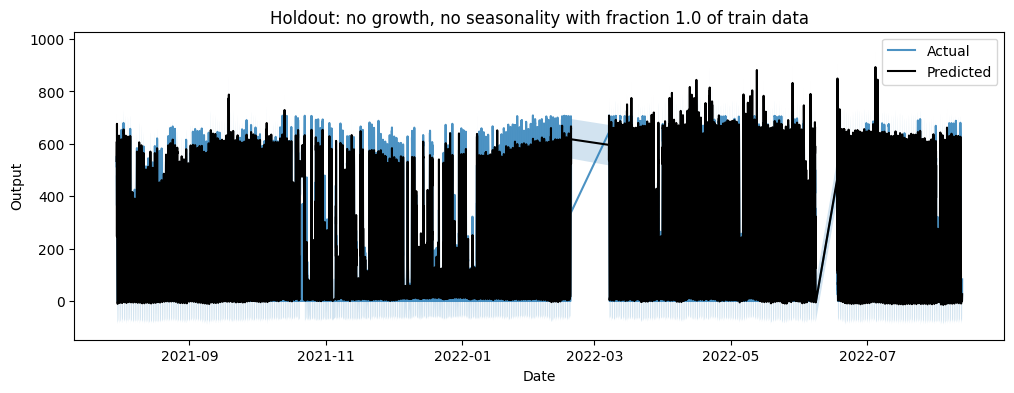

In [27]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# Validation
num_models= 4
mses = np.zeros((num_models, len(splits)))

# 0) Prepare full train data
split_idx = int(len(df_2107_meter) * 0.8)
df = df_2107_meter.rename(columns={
    'measured_on': 'ds',
    'meter_revenue_grade_ac_output_meter_149578': 'y'
}).copy().iloc[:split_idx]

df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values('ds').reset_index(drop=True)

# sets a split counter
i=0

# 1) 8:2 split of 50%, 60%, ..., 100% of train data (time order)

for f, tr, va in splits:
    ttrain = df.iloc[tr].copy()
    holdout = df.iloc[va].copy()


    #  Fit Prophet on ttrain
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=True)
    m.add_regressor('ambient_temperature_o_149575')
    m.add_regressor('poa_irradiance_o_149574')

    m.fit(ttrain[['ds', 'y', 'ambient_temperature_o_149575', 'poa_irradiance_o_149574']])

    #  Predict on holdout
    holdout_future = holdout[['ds', 'ambient_temperature_o_149575', 'poa_irradiance_o_149574']].copy()
    holdout_fcst = m.predict(holdout_future)

    # MSE on holdout
    mse = mean_squared_error(holdout['y'], holdout_fcst['yhat'])
    print("Holdout MSE:", mse)

    # Plot holdout actual vs predicted
    plot_df = holdout[['ds', 'y']].merge(
        holdout_fcst[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
        on='ds', how='left'
    )

    plt.figure(figsize=(12,4))
    plt.plot(plot_df['ds'], plot_df['y'], label='Actual', alpha=0.8)
    plt.plot(plot_df['ds'], plot_df['yhat'], label='Predicted', color='black')
    plt.fill_between(plot_df['ds'], plot_df['yhat_lower'], plot_df['yhat_upper'], alpha=0.2)
    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("Output")
    plt.title(f"Holdout: Actual vs Predicted with fraction {f} of train data")
    plt.show()

    mses[0, i]= mse





    #  Fit Prophet on ttrain
    m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=True)
    m.add_regressor('ambient_temperature_o_149575')
    m.add_regressor('poa_irradiance_o_149574')

    m.fit(ttrain[['ds', 'y', 'ambient_temperature_o_149575', 'poa_irradiance_o_149574']])

    #  Predict on holdout
    holdout_future = holdout[['ds', 'ambient_temperature_o_149575', 'poa_irradiance_o_149574']].copy()
    holdout_fcst = m.predict(holdout_future)

    # MSE on holdout
    mse = mean_squared_error(holdout['y'], holdout_fcst['yhat'])
    print("Holdout MSE:", mse)

    # Plot holdout actual vs predicted
    plot_df = holdout[['ds', 'y']].merge(
        holdout_fcst[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
        on='ds', how='left'
    )

    plt.figure(figsize=(12,4))
    plt.plot(plot_df['ds'], plot_df['y'], label='Actual', alpha=0.8)
    plt.plot(plot_df['ds'], plot_df['yhat'], label='Predicted', color='black')
    plt.fill_between(plot_df['ds'], plot_df['yhat_lower'], plot_df['yhat_upper'], alpha=0.2)
    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("Output")
    plt.title(f"Holdout: no yearly seasonality with fraction {f} of train data")
    plt.show()

    mses[1, i]= mse







    #  Fit Prophet on ttrain
    m = Prophet(yearly_seasonality=False , weekly_seasonality=False, daily_seasonality=False)
    m.add_regressor('ambient_temperature_o_149575')
    m.add_regressor('poa_irradiance_o_149574')

    m.fit(ttrain[['ds', 'y', 'ambient_temperature_o_149575', 'poa_irradiance_o_149574']])

    #  Predict on holdout
    holdout_future = holdout[['ds', 'ambient_temperature_o_149575', 'poa_irradiance_o_149574']].copy()
    holdout_fcst = m.predict(holdout_future)

    # MSE on holdout
    mse = mean_squared_error(holdout['y'], holdout_fcst['yhat'])
    print("Holdout MSE:", mse)

    # Plot holdout actual vs predicted
    plot_df = holdout[['ds', 'y']].merge(
        holdout_fcst[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
        on='ds', how='left'
    )

    plt.figure(figsize=(12,4))
    plt.plot(plot_df['ds'], plot_df['y'], label='Actual', alpha=0.8)
    plt.plot(plot_df['ds'], plot_df['yhat'], label='Predicted', color='black')
    plt.fill_between(plot_df['ds'], plot_df['yhat_lower'], plot_df['yhat_upper'], alpha=0.2)
    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("Output")
    plt.title(f"Holdout: no seasonality with fraction {f} of train data")
    plt.show()

    mses[2, i]= mse



    #  Fit Prophet on ttrain
    m = Prophet(growth = 'flat', yearly_seasonality=False , weekly_seasonality=False, daily_seasonality=False)
    m.add_regressor('ambient_temperature_o_149575')
    m.add_regressor('poa_irradiance_o_149574')

    m.fit(ttrain[['ds', 'y', 'ambient_temperature_o_149575', 'poa_irradiance_o_149574']])

    #  Predict on holdout
    holdout_future = holdout[['ds', 'ambient_temperature_o_149575', 'poa_irradiance_o_149574']].copy()
    holdout_fcst = m.predict(holdout_future)

    # MSE on holdout
    mse = mean_squared_error(holdout['y'], holdout_fcst['yhat'])
    print("Holdout MSE:", mse)

    # Plot holdout actual vs predicted
    plot_df = holdout[['ds', 'y']].merge(
        holdout_fcst[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
        on='ds', how='left'
    )

    plt.figure(figsize=(12,4))
    plt.plot(plot_df['ds'], plot_df['y'], label='Actual', alpha=0.8)
    plt.plot(plot_df['ds'], plot_df['yhat'], label='Predicted', color='black')
    plt.fill_between(plot_df['ds'], plot_df['yhat_lower'], plot_df['yhat_upper'], alpha=0.2)
    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("Output")
    plt.title(f"Holdout: no growth, no seasonality with fraction {f} of train data")
    plt.show()

    mses[3, i]= mse







    i+=1

In [43]:
print(mses)
print(f'Model means and stds \n{mses.mean(axis = 1).round(2)} \n{ mses.std(axis =1).round(2)}')

[[103743.64783802   7433.16143954   3121.22396361   2351.46257371
    3315.37108013   3708.18413224]
 [  3388.20761237   3915.38203993   3276.20967154   2343.13447051
    3397.53062979   3905.65687733]
 [  4164.88969382   5790.54938286   5298.28903599   3415.85063838
    4640.78280627   5069.63884987]
 [  3422.28480828   3939.39906521   3722.10906976   3247.89261738
    4399.3505577    4925.3586826 ]]
Model means and stds 
[20612.18  3371.02  4730.    3942.73] 
[37212.99   524.2    776.46   573.94]


14:23:11 - cmdstanpy - INFO - Chain [1] start processing
14:24:02 - cmdstanpy - INFO - Chain [1] done processing


Holdout MSE: 3275.5836499223665


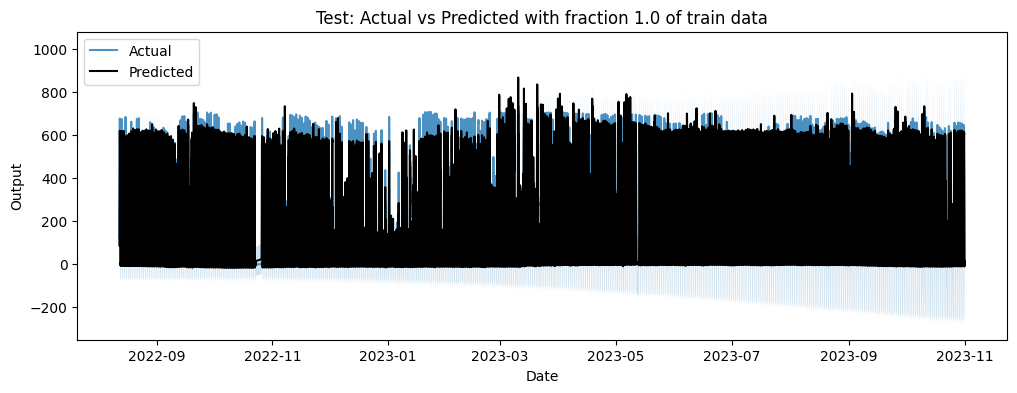

In [30]:
# Test on test set (20% of original data)
num_models= 1
mse = 0

# 0) Prepare full train data
split_idx = int(len(df_2107_meter) * 0.8)
df_train= df_2107_meter.rename(columns={
    'measured_on': 'ds',
    'meter_revenue_grade_ac_output_meter_149578': 'y'
}).copy().iloc[:split_idx]

df_test= df_2107_meter.rename(columns={
    'measured_on': 'ds',
    'meter_revenue_grade_ac_output_meter_149578': 'y'
}).copy().iloc[split_idx:]



#  Fit Prophet on df_train
m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=True)
m.add_regressor('ambient_temperature_o_149575')
m.add_regressor('poa_irradiance_o_149574')

m.fit(df_train[['ds', 'y', 'ambient_temperature_o_149575', 'poa_irradiance_o_149574']])

#  Predict on holdout
holdout_future = df_test[['ds', 'ambient_temperature_o_149575', 'poa_irradiance_o_149574']].copy()
holdout_fcst = m.predict(holdout_future)

# MSE on holdout
mse = mean_squared_error(df_test['y'], holdout_fcst['yhat'])
print("Holdout MSE:", mse)

# Plot holdout actual vs predicted
plot_df = df_test[['ds', 'y']].merge(
    holdout_fcst[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds', how='left'
)

plt.figure(figsize=(12,4))
plt.plot(plot_df['ds'], plot_df['y'], label='Actual', alpha=0.8)
plt.plot(plot_df['ds'], plot_df['yhat'], label='Predicted', color='black')
plt.fill_between(plot_df['ds'], plot_df['yhat_lower'], plot_df['yhat_upper'], alpha=0.2)
plt.legend()
plt.xlabel("Date")
plt.ylabel("Output")
plt.title(f"Test: Actual vs Predicted with fraction {f} of train data")
plt.show()